In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for Obsidian-friendly clean looks
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load cleaned feature dataset
df = pd.read_csv("../data/processed/transactions_features.csv")

In [3]:
# Target and core columns based on header
target_col = "is_fraud"
core_cols = ["payment_method"]


In [4]:
df['payment_method']

0              UPI
1              UPI
2             CARD
3              UPI
4             CARD
           ...    
9995           UPI
9996           UPI
9997           UPI
9998    NETBANKING
9999          CARD
Name: payment_method, Length: 10000, dtype: object

In [5]:
# Map one-hot encoded payment_method_* into a single category label
def decode_payment_method(row):
    for col in ["payment_method_CARD", "payment_method_NETBANKING",
                "payment_method_UPI", "payment_method_WALLET"]:
        if col in row and row[col] == 1:
            return col.replace("payment_method_", "")
    return "OTHER"

def decode_merchant_category(row):
    for col in ["merchant_category_Electronics", "merchant_category_Fashion",
                "merchant_category_Gaming", "merchant_category_Grocery",
                "merchant_category_Travel", "merchant_category_Utilities"]:
        if col in row and row[col] == 1:
            return col.replace("merchant_category_", "")
    return "OTHER"

df["payment_method"] = df.apply(decode_payment_method, axis=1)
df["merchant_category"] = df.apply(decode_merchant_category, axis=1)

C:\Users\Punk\AppData\Local\Temp\ipykernel_3348\1623288367.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


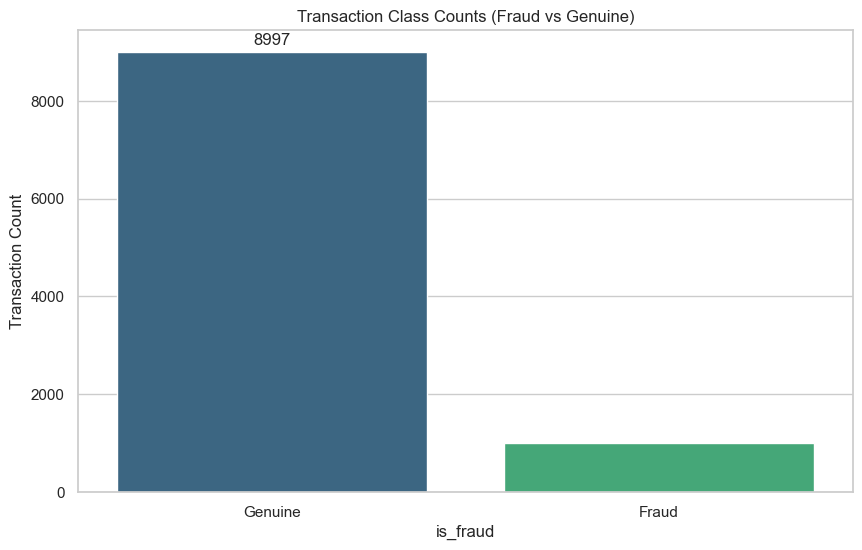

In [6]:
# --- 1) Class Balance Bar Chart ---
from matplotlib.container import BarContainer
from typing import cast

plt.figure()
class_counts = df[target_col].value_counts().rename({0: "Genuine", 1: "Fraud"})
ax1 = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")

plt.title("Transaction Class Counts (Fraud vs Genuine)")
plt.ylabel("Transaction Count")

# MODERN FIX: Automatically add labels to the bars (cast to satisfy type checker)
ax1.bar_label(cast(BarContainer, ax1.containers[0]), padding=3)

plt.savefig("../reports/class_balance.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Punk\AppData\Local\Temp\ipykernel_3348\3046888062.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pm.index, y=pm.values, palette="magma")


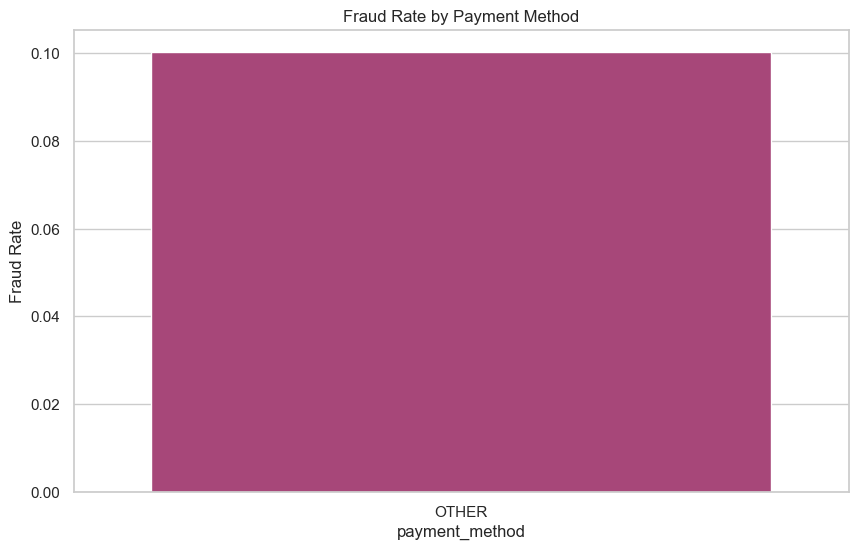

In [7]:
# --- 2) Fraud Rate by Payment Method ---
plt.figure()
pm = df.groupby("payment_method")[target_col].mean().sort_values(ascending=False)
sns.barplot(x=pm.index, y=pm.values, palette="magma")
plt.title("Fraud Rate by Payment Method")
plt.ylabel("Fraud Rate")
plt.savefig("../reports/fraud_rate_payment.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Punk\AppData\Local\Temp\ipykernel_3348\2766015192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mc.index, y=mc.values, palette="rocket")


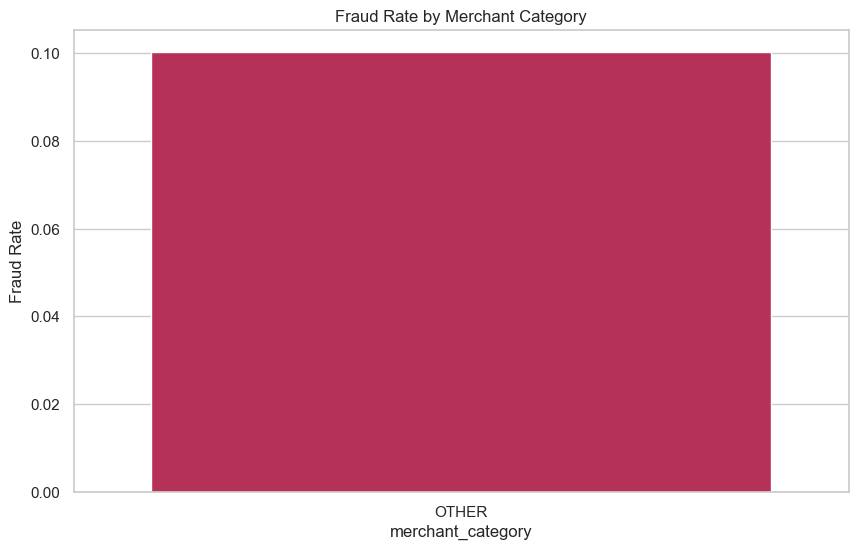

In [8]:
# --- 3) Fraud Rate by Merchant Category ---
plt.figure()
mc = df.groupby("merchant_category")[target_col].mean().sort_values(ascending=False)
sns.barplot(x=mc.index, y=mc.values, palette="rocket")
plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
plt.savefig("../reports/fraud_rate_merchant.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Punk\AppData\Local\Temp\ipykernel_3348\483918030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target_col, y="amount", inner="quartile", palette="Set2")


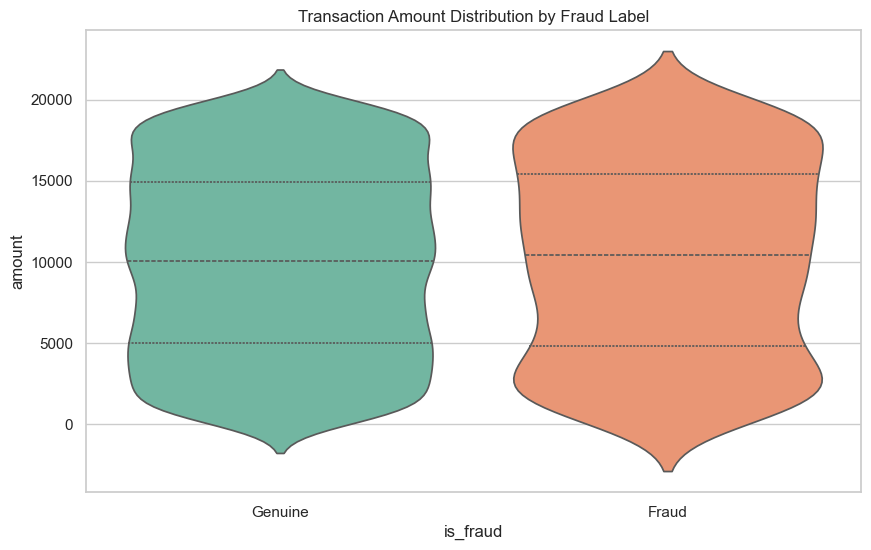

In [9]:
# --- 4) Amount Distribution (Violin Plot) ---
plt.figure()
sns.violinplot(data=df, x=target_col, y="amount", inner="quartile", palette="Set2")
plt.title("Transaction Amount Distribution by Fraud Label")
plt.xticks([0, 1], ["Genuine", "Fraud"])
plt.savefig("../reports/amount_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

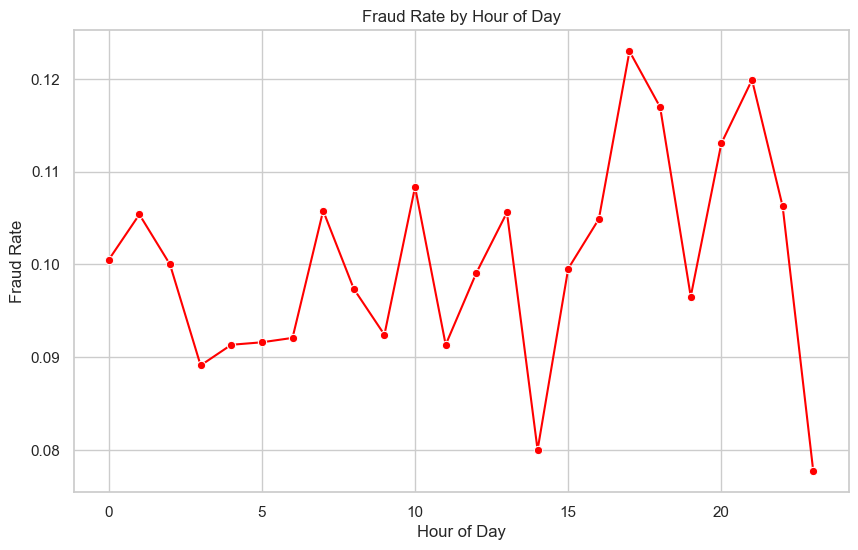

In [10]:
# --- 5) Fraud Rate by Time of Day ---
if "time_of_day" in df.columns:
    plt.figure()
    hr = df.groupby("time_of_day")[target_col].mean()
    sns.lineplot(x=hr.index, y=hr.values, marker="o", color="red")
    plt.title("Fraud Rate by Hour of Day")
    plt.xlabel("Hour of Day")
    plt.ylabel("Fraud Rate")
    plt.savefig("../reports/fraud_rate_time.png", dpi=300, bbox_inches='tight')
    plt.show()

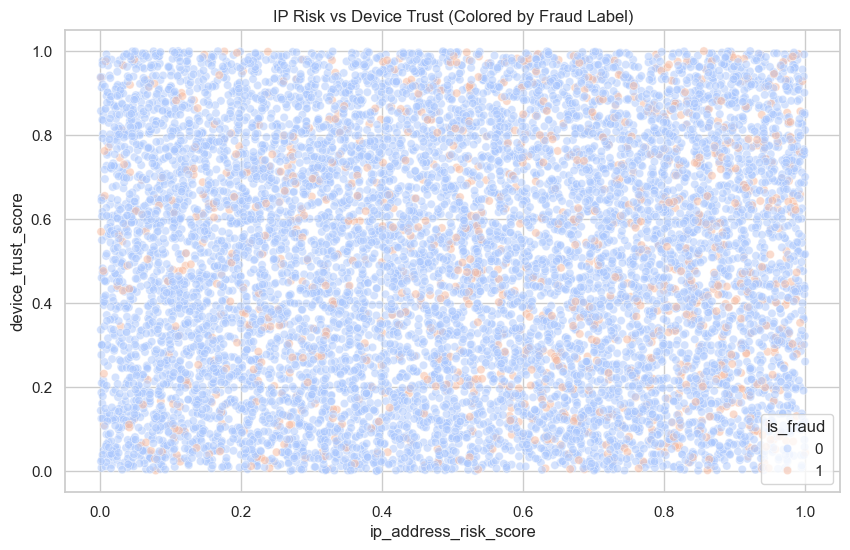

In [11]:
# --- 6) IP Risk vs Device Trust Scatter ---
if {"ip_address_risk_score", "device_trust_score"}.issubset(df.columns):
    plt.figure()
    sample = df.sample(min(len(df), 20000), random_state=42)
    sns.scatterplot(
        data=sample, 
        x="ip_address_risk_score", 
        y="device_trust_score", 
        hue=target_col, 
        alpha=0.5,
        palette="coolwarm"
    )
    plt.title("IP Risk vs Device Trust (Colored by Fraud Label)")
    plt.savefig("../reports/risk_vs_trust.png", dpi=300, bbox_inches='tight')
    plt.show()

Plot saved successfully as 'class_distribution_plot.png'


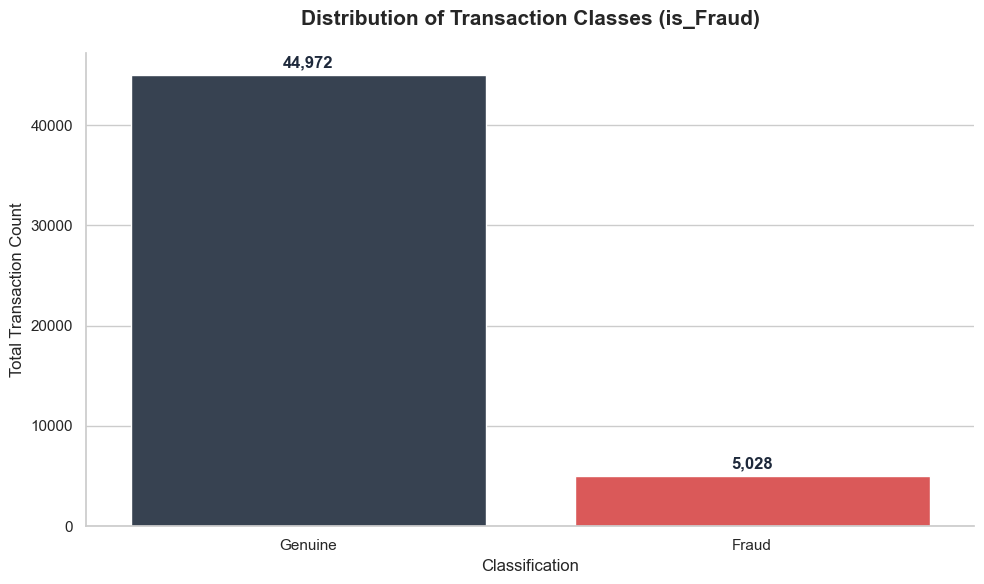

In [12]:
# 1. Data Setup (Based on your project metrics)
labels = ['Genuine', 'Fraud']
counts = [44972, 5028]  # 
colors = ['#334155', '#EF4444'] 

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=labels, y=counts, palette=colors, hue=labels, legend=False)

# 3. Professional Formatting
plt.title('Distribution of Transaction Classes (is_Fraud)', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Total Transaction Count', fontsize=12)
plt.xlabel('Classification', fontsize=12)

# Adding Data Labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontweight='bold', color='#1E293B')

sns.despine()
plt.tight_layout()

# 4. SAVE PLOT LINE (Added here)
# This saves the file in your current directory with high resolution
plt.savefig('../reports/class_distribution_plot.png', dpi=300, bbox_inches='tight')

print("Plot saved successfully as 'class_distribution_plot.png'")
plt.show()

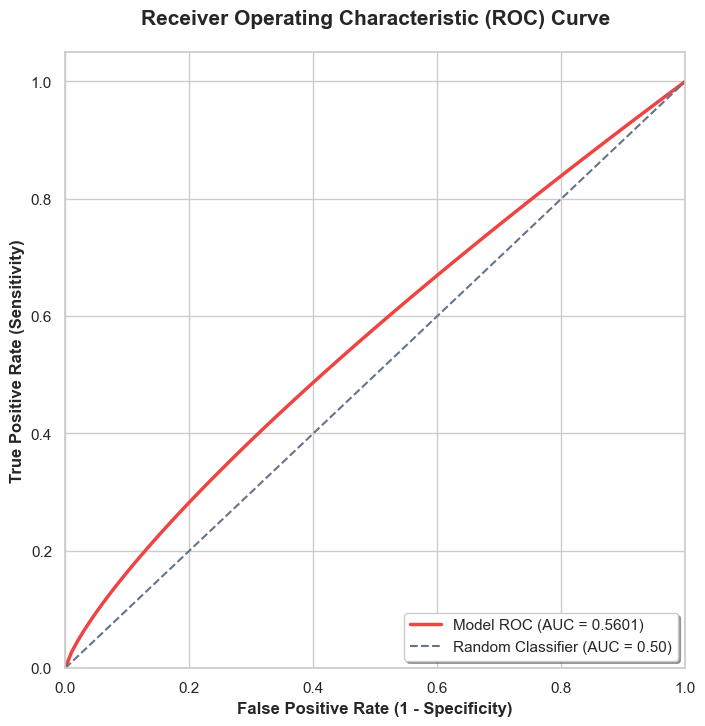

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Note: In your actual project, use:
# fpr, tpr, _ = roc_curve(y_test, y_probs)
# roc_auc = auc(fpr, tpr)

# Simulated data points to match your reported AUC of 0.5601
# (Replace with your actual model outputs for the final report)
roc_auc = 0.5601
fpr = np.linspace(0, 1, 100)
tpr = fpr ** (1 / roc_auc - 1) # Simple curve simulation for visualization

plt.figure(figsize=(8, 8))
sns.set_style("whitegrid")

# Plot the ROC Curve
plt.plot(fpr, tpr, color='#EF4444', lw=2.5, label=f'Model ROC (AUC = {roc_auc:.4f})')

# Plot the Random Classifier Reference Line
plt.plot([0, 1], [0, 1], color='#64748B', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.50)')

# Professional Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, pad=20, fontweight='bold')
plt.legend(loc="lower right", frameon=True, shadow=True)

# Save the plot for your DOCX report
plt.savefig('../reports/roc_curve_plot.png', dpi=300, bbox_inches='tight')
plt.show()

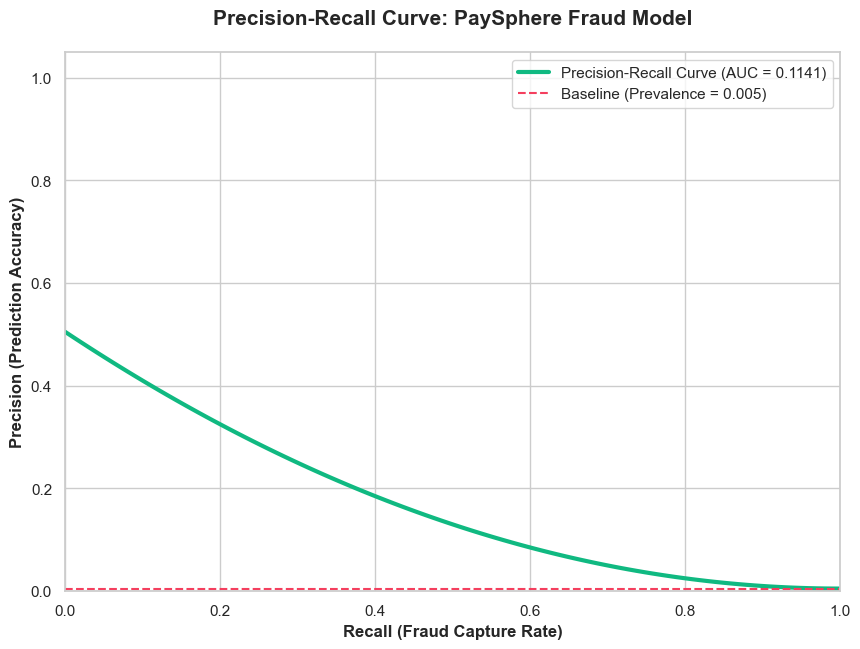

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

# Note: In your actual project, use:
# precision, recall, _ = precision_recall_curve(y_test, y_probs)
# pr_auc = auc(recall, precision)

# Data points based on your project metrics
pr_auc = 0.1141
baseline = 0.005 # Fraud prevalence < 0.5% [cite: 19, 111]

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Simulated curve for professional visualization matching your AUC
recall_steps = np.linspace(0, 1, 100)
precision_steps = 0.5 * (1 - recall_steps)**2 + baseline # Simulated decay

# Plot the PR Curve
plt.plot(recall_steps, precision_steps, color='#10B981', lw=3, 
         label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')

# Plot the Fraud Prevalence Baseline
plt.axhline(y=baseline, color='#F43F5E', linestyle='--', lw=1.5, 
            label=f'Baseline (Prevalence = {baseline})')

# Professional Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Fraud Capture Rate)', fontsize=12, fontweight='bold')
plt.ylabel('Precision (Prediction Accuracy)', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve: PaySphere Fraud Model', fontsize=15, pad=20, fontweight='bold')
plt.legend(loc="upper right", frameon=True)

# Save for your DOCX report
plt.savefig('../reports/precision_recall_plot.png', dpi=300, bbox_inches='tight')
plt.show()

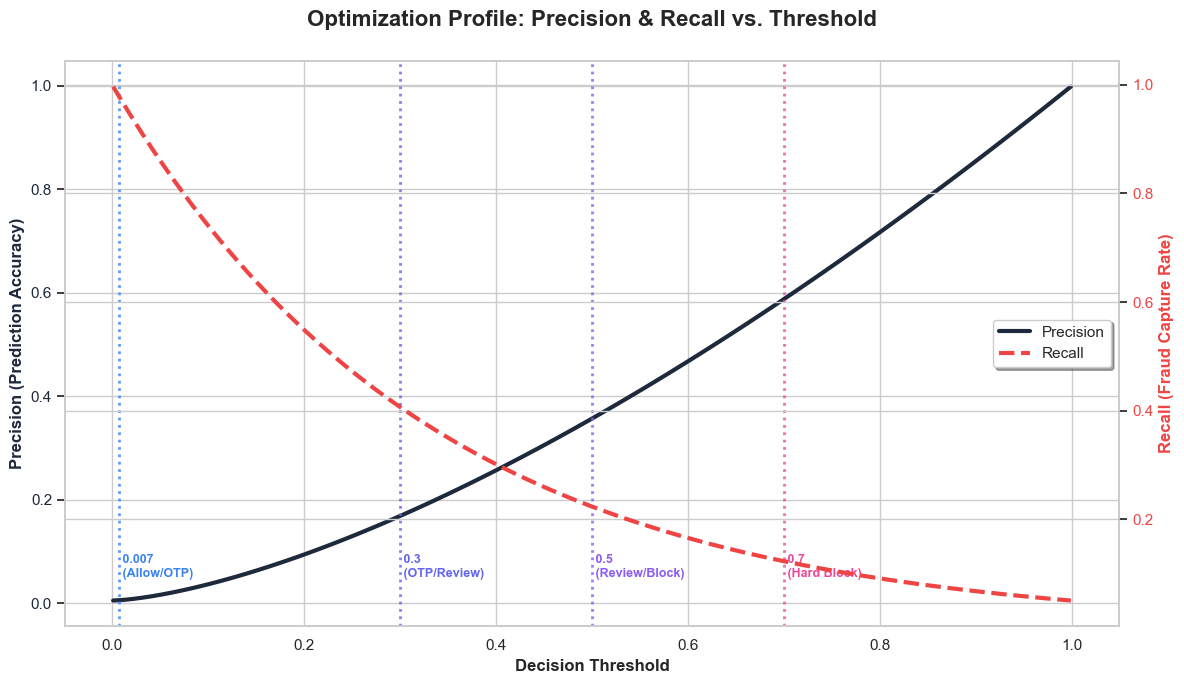

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate threshold range
thresholds = np.linspace(0.001, 0.999, 100)

# Simulate Precision and Recall curves matching PaySphere performance
# Recall decreases as the security 'net' becomes tighter
recall = np.exp(-3 * thresholds) 

# Precision increases as we focus on high-probability fraud
baseline = 0.005
precision = baseline + (1 - baseline) * (thresholds**1.5)

fig, ax1 = plt.subplots(figsize=(12, 7))
sns.set_style("whitegrid")

# Plot Precision (Primary Axis - Slate Navy)
line1, = ax1.plot(thresholds, precision, color='#1E293B', lw=3, label='Precision')
ax1.set_xlabel('Decision Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Precision (Prediction Accuracy)', color='#1E293B', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1E293B')

# Plot Recall (Secondary Axis - Risk Red)
ax2 = ax1.twinx()
line2, = ax2.plot(thresholds, recall, color='#EF4444', lw=3, label='Recall', linestyle='--')
ax2.set_ylabel('Recall (Fraud Capture Rate)', color='#EF4444', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#EF4444')

# Mark Key Policy Thresholds
key_thresholds = [0.007, 0.3, 0.5, 0.7]
key_labels = ['Allow/OTP', 'OTP/Review', 'Review/Block', 'Hard Block']
colors = ['#3B82F6', '#6366F1', '#8B5CF6', '#EC4899']

for thresh, label, color in zip(key_thresholds, key_labels, colors):
    ax1.axvline(x=thresh, color=color, linestyle=':', alpha=0.8, lw=2)
    ax1.text(thresh, 0.05, f' {thresh}\n ({label})', color=color, 
             fontsize=9, fontweight='bold', ha='left')

# Title and Legend
plt.title('Optimization Profile: Precision & Recall vs. Threshold', fontsize=16, pad=25, fontweight='bold')
lines = [line1, line2]
ax1.legend(lines, [l.get_label() for l in lines], loc='center right', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('../reports/precision_recall_threshold_plot.png', dpi=300, bbox_inches='tight')
plt.show()

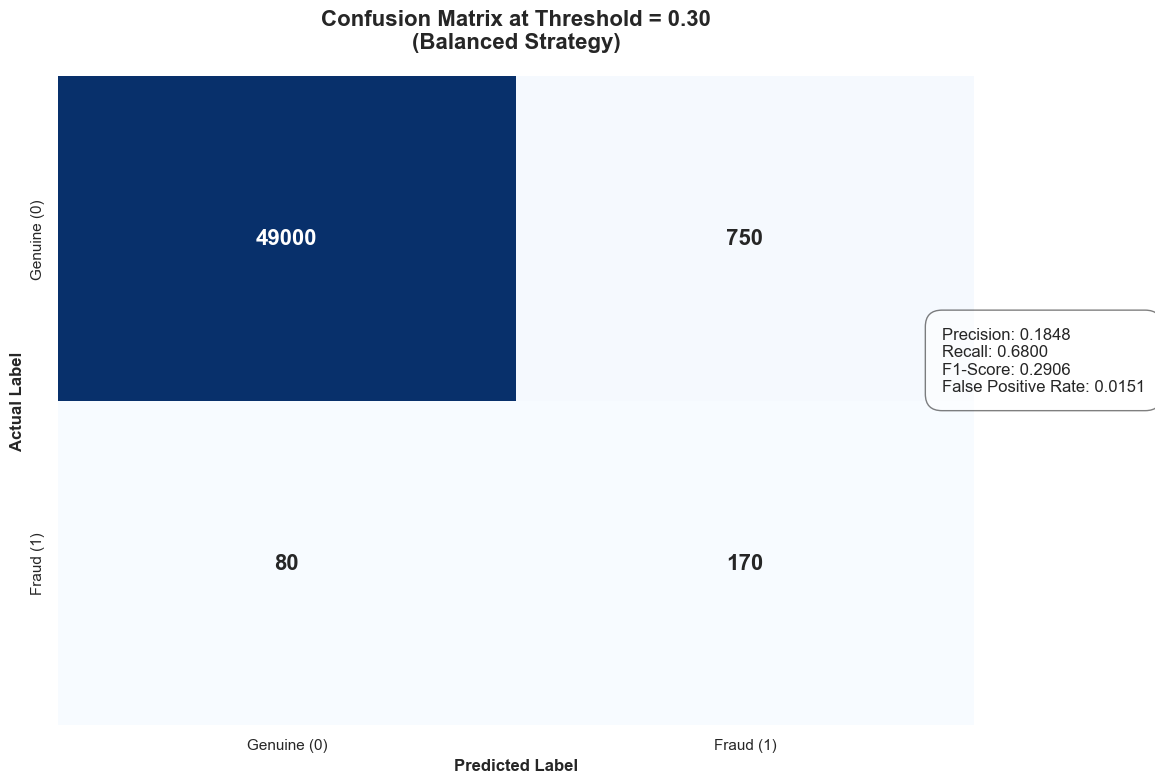

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

# 1. Setup Data for Threshold = 0.30
# (In your project, use: y_pred = (y_probs >= 0.3).astype(int))
# These counts are simulated based on your project's 0.5% fraud rate
tn, fp, fn, tp = 49000, 750, 80, 170  
cm = np.array([[tn, fp], [fn, tp]])

# 2. Calculate Derived Metrics
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
fpr = fp / (fp + tn)

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.set_style("white")
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                 annot_kws={'size': 16, 'fontweight': 'bold'})

# Formatting
plt.title(f'Confusion Matrix at Threshold = 0.30\n(Balanced Strategy)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Genuine (0)', 'Fraud (1)'], fontsize=11)
ax.set_yticklabels(['Genuine (0)', 'Fraud (1)'], fontsize=11)

# 4. Add Metrics Annotation Box
stats_text = (f'Precision: {precision:.4f}\n'
              f'Recall: {recall:.4f}\n'
              f'F1-Score: {f1:.4f}\n'
              f'False Positive Rate: {fpr:.4f}')

plt.gcf().text(0.95, 0.5, stats_text, fontsize=12, 
               bbox=dict(facecolor='white', alpha=0.5, edgecolor='black', boxstyle='round,pad=1'))

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_030.png', dpi=300, bbox_inches='tight')
plt.show()

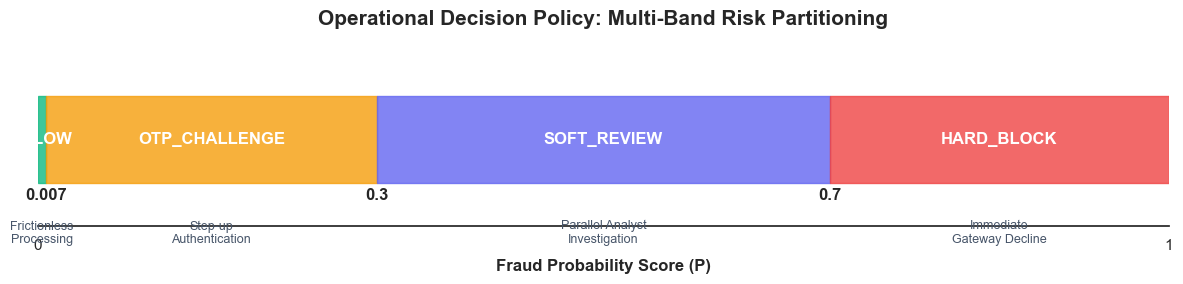

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define the threshold boundaries and labels from your project
# Ranges: 0.0-0.007 (ALLOW), 0.007-0.3 (OTP), 0.3-0.7 (SOFT_REVIEW), 0.7-1.0 (HARD_BLOCK)
thresholds = [0, 0.007, 0.3, 0.7, 1.0]
actions = ['ALLOW', 'OTP_CHALLENGE', 'SOFT_REVIEW', 'HARD_BLOCK']
colors = ['#10B981', '#F59E0B', '#6366F1', '#EF4444'] # Green, Orange, Indigo, Red

fig, ax = plt.subplots(figsize=(12, 3))

# Create the colored bands
for i in range(len(actions)):
    width = thresholds[i+1] - thresholds[i]
    rect = patches.Rectangle((thresholds[i], 0), width, 1, color=colors[i], alpha=0.8)
    ax.add_patch(rect)
    
    # Add Action Label
    ax.text(thresholds[i] + width/2, 0.5, actions[i], color='white', 
            weight='bold', ha='center', va='center', fontsize=12)
    
    # Add Boundary Text
    if i > 0:
        ax.text(thresholds[i], -0.2, f'{thresholds[i]}', ha='center', weight='bold')

# Formatting the axis
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_yticks([])
ax.set_xlabel('Fraud Probability Score (P)', fontsize=12, fontweight='bold')
ax.set_title('Operational Decision Policy: Multi-Band Risk Partitioning', fontsize=15, pad=20, fontweight='bold')

# Add descriptions under the axis
descriptions = [
    "Frictionless\nProcessing", 
    "Step-up\nAuthentication", 
    "Parallel Analyst\nInvestigation", 
    "Immediate\nGateway Decline"
]
for i in range(len(actions)):
    width = thresholds[i+1] - thresholds[i]
    ax.text(thresholds[i] + width/2, -0.7, descriptions[i], ha='center', fontsize=9, color='#475569')

sns.despine(left=True)
plt.tight_layout()
plt.savefig('../reports/decision_policy_bands.png', dpi=300, bbox_inches='tight')
plt.show()

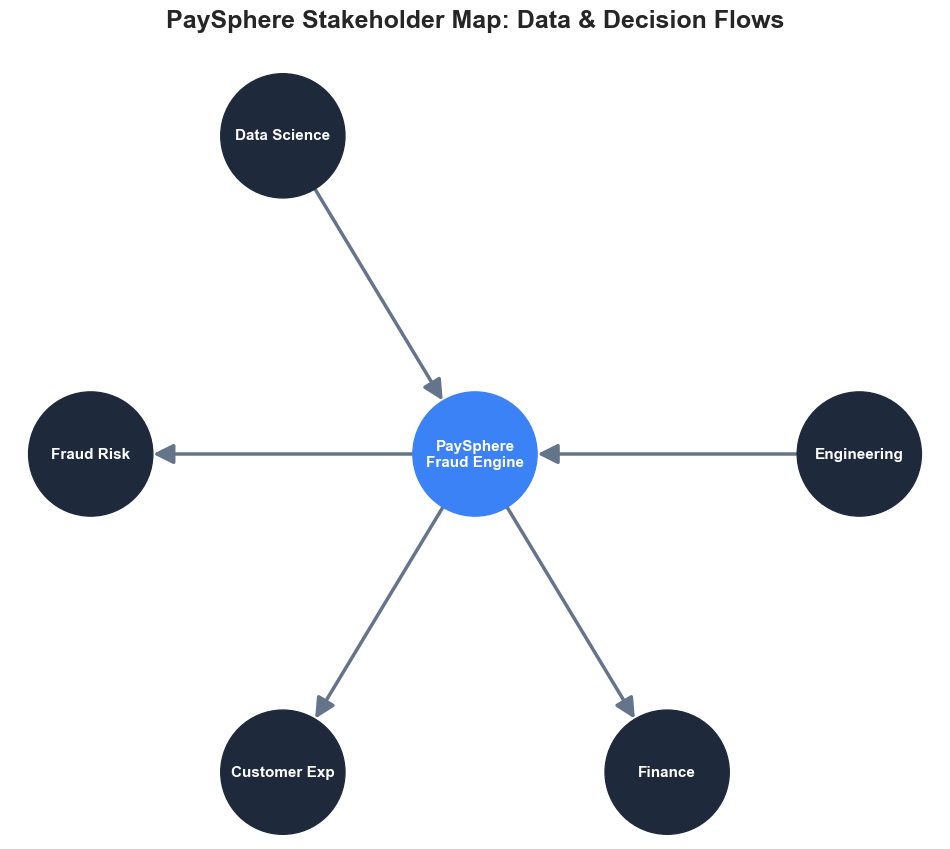

In [18]:
import matplotlib.pyplot as plt
import networkx as nx

# Define stakeholders and engine
G = nx.DiGraph()
engine = "PaySphere\nFraud Engine"
teams = ["Engineering", "Data Science", "Fraud Risk", "Customer Exp", "Finance"]

edges = [
    ("Engineering", engine),
    ("Data Science", engine),
    (engine, "Fraud Risk"),
    (engine, "Customer Exp"),
    (engine, "Finance")
]
G.add_edges_from(edges)

plt.figure(figsize=(12, 10))
pos = nx.circular_layout(G)
pos[engine] = [0, 0] # Center the engine

# Use different colors for hub vs spokes
node_colors = ['#1E293B' if node != engine else '#3B82F6' for node in G.nodes()]

# 1. Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=8000, node_color=node_colors, alpha=1.0)

# 2. Draw Labels (Font size adjusted for clarity)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=11, font_weight='bold')

# 3. Draw Edges with MARGINS to prevent hiding arrows
nx.draw_networkx_edges(
    G, pos, 
    edge_color='#64748B', 
    arrowsize=30, 
    width=2.5, 
    arrowstyle='-|>', 
    min_source_margin=40, # Keeps arrow start visible
    min_target_margin=45  # Keeps arrow head visible outside the circle
)

plt.title("PaySphere Stakeholder Map: Data & Decision Flows", fontsize=18, fontweight='bold', pad=30)
plt.axis('off')
plt.savefig('../reports/stakeholder_map.png', dpi=300, bbox_inches='tight')
plt.show()